In [22]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc', decode_timedelta=True) #***
# res='1km';t_res='5min'
# Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'

# dx = 250km; Np = 50M;
#Importing Model Data
dir2='/home/air673/koa_scratch/'
data1=xr.open_dataset(dir2+'cm1out_250m_1min_50M.nc', decode_timedelta=True) #***
parcel1=xr.open_dataset(dir2+'cm1out_pdata_250m_1min_50M.nc', decode_timedelta=True) #***
res='250m'; t_res='1min'; Np_str='50e6'

In [23]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

#####

#Import StatisticalFunctions 
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import StatisticalFunctions
from StatisticalFunctions import * # import NumericalFunctions 

In [24]:
##########################################################################################
#Plotting
plotting=False #KEEP FALSE WHEN JOB_ARRAYS IS RUNNING
plotting=True

In [25]:
#READING BACK IN
# import pickle
# dir2 = dir + f'Project_Algorithms/Domain_Profiles/'
# input_file = dir2 + f'mean_lfc_{res}_{t_res}_{Np_str}.pkl'

# with open(input_file, 'rb') as f:
#     mean_LFC = pickle.load(f)
# print(mean_LFC)

def LoadMeanLFC():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"MeanLFC_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        MeanLFC = pickle.load(f)
    return MeanLFC
MeanLFC=LoadMeanLFC()
mean_LFC=MeanLFC
print(f"Mean LFC is: {MeanLFC}\n")


def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {cloudbase}\n")

Mean LFC is: 1765.9480174164744

Minimum Cloudbase is: 0.8750000596046448



In [26]:
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] > 1)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

In [27]:
def GetVars(var_names,type1):
    dir2=dir+'Project_Algorithms/Domain_Profiles/'
    input_file = dir2 + f'job_out/{type1}_eulerian_entrainment_profiles_{res}_{t_res}_{Np_str}.h5'
    with h5py.File(input_file, 'r') as f:
        for var in var_names:
            globals()[f"{var}_{type1[0]}"] = f[f"profile_array_{var}_{type1[0]}"][:]

            globals()[f"{var}_{type1[0]}_SE"]=ProfileStandardError(f[f"profile_array_{var}_{type1[0]}"][:],f[f"profile_array_{var}_{type1[0]}_squares"][:])
            # globals()[f"{var}_{type1[0]}_SE"]=ProfileStandardDeviation(f[f"profile_array_{var}_{type1[0]}"][:],f[f"profile_array_{var}_{type1[0]}_squares"][:])

var_names=['e','d','net']
# # --- Load General ---
type1='general'
GetVars(var_names,type1)
# # --- Load Cloudy ---
type1='cloudy'
GetVars(var_names,type1)

In [28]:
def load_entrainment_transition_profiles(dir_path= dir + 'Project_Algorithms/Domain_Profiles/'):
    input_file_general = dir_path + f'job_out/general_eulerian_combined_entrainment_profiles_{res}_{t_res}_{Np_str}.h5'
    input_file_cloudy = dir_path + f'job_out/cloudy_eulerian_combined_entrainment_profiles_{res}_{t_res}_{Np_str}.h5'

    with h5py.File(input_file_general, 'r') as f:
        c_to_g_general = np.array(f['profile_array_c_to_g'])

    with h5py.File(input_file_cloudy, 'r') as f:
        g_to_c_cloudy = np.array(f['profile_array_g_to_c'])

    return c_to_g_general, g_to_c_cloudy

c_to_g_general, g_to_c_cloudy = load_entrainment_transition_profiles()

In [29]:
import matplotlib.pyplot as plt

def plot_entrainment_profiles(ax, factor=1, lw=1.2):
    var_names = ['e', 'd', 'net']
    colors = {'e': 'blue', 'd': 'red', 'net': 'k'}
    styles = {'g': '--', 'c': '-'}

    # --- Process Both Types ---
    out_e_g = averaged_profiles(e_g)
    out_d_g = averaged_profiles(d_g)
    out_net_g = averaged_profiles(net_g)

    out_e_c = averaged_profiles(e_c)
    out_d_c = averaged_profiles(d_c)
    out_net_c = averaged_profiles(net_c)
    
    for suffix in ['g', 'c']:
        for var in var_names:
            varname = f'out_{var}_{suffix}'
            profile = locals()[varname]
            profile_SE_name = f'{var}_{suffix}_SE'
            profile_SE = globals().get(profile_SE_name, None) 

            label_suffix = 'general' if suffix == 'g' else 'cloudy'
            ax.plot(
                profile[:, 0],
                profile[:, 1],
                color=colors[var],
                linestyle=styles[suffix],
                linewidth=lw,
                label=f'{var} ({label_suffix})'
            )

            # Uncomment below if you want to plot error shading and SE data exists
            if profile_SE is not None:
                hatch = '///' if suffix == 'g' else ""
                ax.fill_betweenx(
                    profile[:, 1],
                    profile[:, 0] - factor * profile_SE[:, 0],
                    profile[:, 0] + factor * profile_SE[:, 0],
                    color=colors[var],
                    alpha=0.1,
                    hatch=hatch
                )

    ax.axvline(0, color='k', linewidth=lw)

    # Apply scientific notation helper if you have one
    apply_scientific_notation([ax])

    # Cloud base and mean LFC lines
    ax.axhline(cloudbase, color='purple', linestyle='dashed', lw=1.2)
    ax.axhline(mean_LFC / 1000, color='green', linestyle='dashed', lw=1.2)

    # ax.set_title('Entrainment: General (dashed) vs Cloudy (solid)')
    ax.legend()

def plot_entrainment_transition_profiles_combined(ax, c_to_g_general, g_to_c_cloudy):
    mean_c_to_g = averaged_profiles(c_to_g_general)
    mean_g_to_c = averaged_profiles(g_to_c_cloudy)
    
    ax.plot(mean_c_to_g[:, 0], mean_c_to_g[:, 1], color='black', label='c_to_g (general)')
    ax.plot(mean_g_to_c[:, 0], mean_g_to_c[:, 1], color='blue', label='g_to_c (cloudy)')
    ax.axvline(0, color='k')

    apply_scientific_notation([ax])  # if you have this function defined

    ax.axhline(cloudbase, color='purple', linestyle='dashed', lw=1.2)
    ax.axhline(mean_LFC / 1000, color='green', linestyle='dashed', lw=1.2)

    # ax.set_title('Entrainment Transition: c_to_g (general) & g_to_c (cloudy)')
    ax.legend()

In [30]:
#RATIO PLOT

def safe_divide(numerator, denominator):
    # result=numerator/denominator
    # Convert to numpy arrays for safety
    numerator = np.array(numerator)
    denominator = np.array(denominator)
    
    # Mask denominator zeros or very small values to avoid divide-by-zero
    mask = (denominator == 0) | np.isnan(denominator) | np.isnan(numerator)
    
    # Create a result array filled with NaNs initially
    result = np.full_like(numerator, np.nan, dtype=float)
    
    # Only divide where denominator is nonzero and both numerator/denominator are finite
    valid = ~mask
    result[valid] = numerator[valid] / denominator[valid]
    
    return result

    
def plot_transfer_ratio(ax, e_g, c_to_g_general, e_c, g_to_c_cloudy, title):
    # Apply averaging
    mean_c_to_g = averaged_profiles(c_to_g_general)  # shape: (N, 2)
    mean_g_to_c = averaged_profiles(g_to_c_cloudy)
    mean_e_g = averaged_profiles(e_g)
    mean_e_c = averaged_profiles(e_c)
    
    ax.plot(safe_divide(mean_c_to_g[:, 0], mean_e_g[:, 0]), mean_c_to_g[:, -1], color='blue', label='Cloudy → General / General Ratio')
    ax.plot(safe_divide(mean_g_to_c[:, 0], mean_e_c[:, 0]), mean_g_to_c[:, -1], color='red', label='General → Cloudy / Cloudy Ratio')
    ax.axvline(1, color='black', linestyle='dashed', linewidth=1)

    ax.axhline(cloudbase, color='purple', linestyle='dashed', lw=1.2)
    ax.axhline(mean_LFC / 1000, color='green', linestyle='dashed', lw=1.2)

    ax.set_title(title)
    ax.set_xlabel('Ratio')
    ax.set_ylabel('Height (km)')

    # Set x-axis limit with padding
    pad_fraction = 0.1
    ax.set_xlim(0, 1*1.1)

    ax.legend()
    apply_scientific_notation([ax])


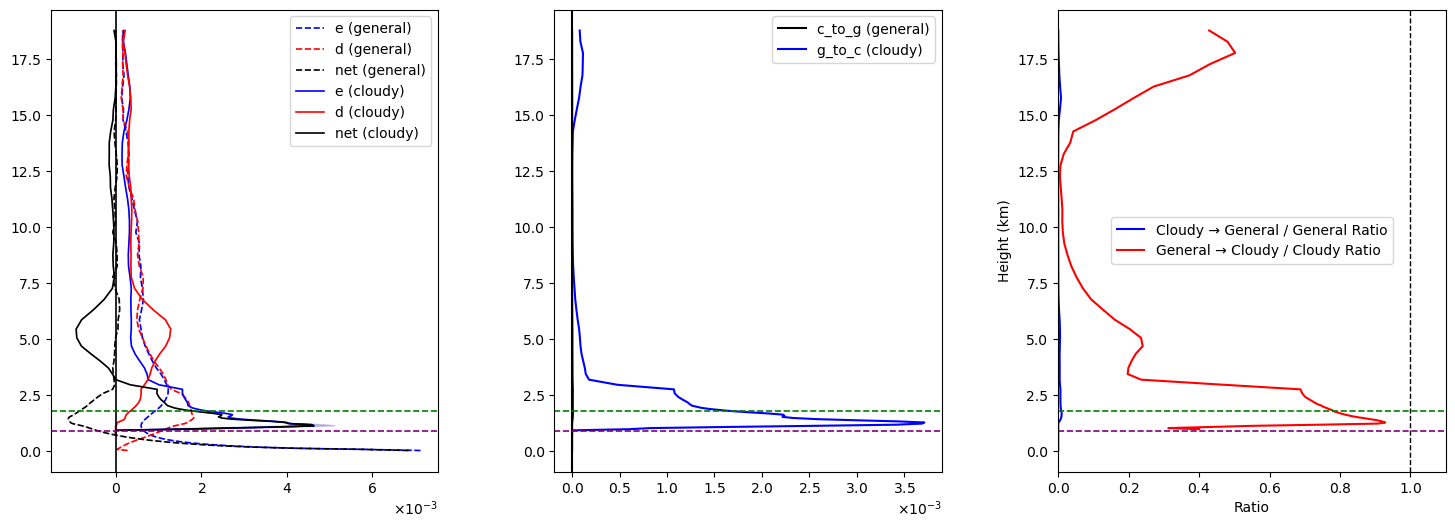

In [31]:
fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

plot_entrainment_profiles(ax1)
plot_entrainment_transition_profiles_combined(ax2, c_to_g_general, g_to_c_cloudy)

plot_transfer_ratio(ax3, e_g, c_to_g_general, e_c, g_to_c_cloudy, title="")

In [ ]:
##################################################
#TESTING

In [ ]:
# #DOUBLE CHECKING
# w=data['winterp'].data
# qc=data['qc'].data
# qi=data['qi'].data
# qcqi=qc+qi
# mask = (w >= 0.5) & (qcqi >= 1e-6)
# profile_array_e_c[~mask] = np.nan
# out=np.nanmean(profile_array_e_c,axis=(0,2,3))
# plt.plot(out,data['zh'])
# ax=plt.gca()
# apply_scientific_notation([ax])

In [ ]:
# #thresholds
# w_thresh1=0.1
# w_thresh2=0.5
# qcqi_thresh=1e-6

In [ ]:
# def plotting(out_var,axis,label,color):
#     axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
#     axis.grid(True)
#     apply_scientific_notation([axis])

# fig, axs = plt.subplots(1, 3, figsize=(15, 10))
# # fig.suptitle()
# ax1,ax2,ax3=axs.flatten()

# for type in ["general","cloudy"]:
#     print(f'currently on type {type}')
#     dir2=dir+'Project_Algorithms/Domain_Profiles/'
#     if type == "general":
#         input_file = dir2+f'job_out/general_eulerian_entrainment_profiles_{res}_{Np_str}_5min.h5' 
#     elif type == "cloudy":
#         input_file = dir2+f'job_out/cloudy_eulerian_entrainment_profiles_{res}_{Np_str}_5min.h5' 

#     with h5py.File(input_file, 'r') as f:
#         if type == "general":
#             e = np.array(f['profile_e_g'])
#             d = np.array(f['profile_d_g'])
#             net = np.array(f['profile_net_g'])
#         elif type == "cloudy":
#             e = np.array(f['profile_e_c'])
#             d = np.array(f['profile_d_c'])
#             net = np.array(f['profile_net_c'])

#     #Uses Averaged_Profiles Function
#     vars = ['e','d','net'] 
    
#     for var in vars:
#         globals()[f"out_{var}"] = averaged_profiles(globals()[f"{var}"])
        
#     axises=[ax1,ax2,ax3] 
#     xlabels=['e','d','net'] 
#     for var,axis,xlabel in zip(vars,axises,xlabels):
#         if type=='general':
#             color='k'
#         elif type=='cloudy':
#             color='blue'

#         plotting(globals()[f"out_{var}"],axis,label=type+' ',color=color)
#         axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);

#         if axis==ax1:
#             axis.legend()
#         axis.axvline(0,color='k')

#     type='cloudy'
#     #MEAN CLOUD BASE
#     dir2=dir+'Project_Algorithms/Domain_Profiles/'
#     if type == "general":
#         input_file = dir2+f'job_out/general_eulerian_profiles_{res}_{Np_str}_5min.h5' 
#     elif type == "cloudy":
#         input_file = dir2+f'job_out/cloudy_eulerian_profiles_{res}_{Np_str}_5min.h5'
    
#     with h5py.File(input_file, 'r') as f:
#         profile_qc = np.array(f['profile_qc'])
#         qcqi_profile=averaged_profiles(profile_qc)
#         where_cloudbase=np.where(qcqi_profile[:,0]>=qcqi_thresh)[0][0]
#         cloudbase=qcqi_profile[where_cloudbase,1]
#         for axis in axises:
#             axis.axhline(cloudbase,color='purple',linestyle='dashed')
        